# Metrics Basics

## Algorithms

See: https://shapely.readthedocs.io/en/stable/measurement.html

### Hausdorff distance
`shapely.hausdorff_distance(a, b, densify=None, **kwargs)`

Compute the discrete Hausdorff distance between two geometries.

The Hausdorff distance is a measure of similarity: it is the greatest distance between any point in A and the closest point in B. The discrete distance is an approximation of this metric: only vertices are considered. The parameter ‘densify’ makes this approximation less coarse by splitting the line segments between vertices before computing the distance.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.

> densify
> - float or array_like, optional
> - The value of densify is required to be between 0 and 1.

### Fréchet distance

`shapely.frechet_distance(a, b, densify=None, **kwargs)`

Compute the discrete Fréchet distance between two geometries.

The Fréchet distance is a measure of similarity: it is the greatest distance between any point in A and the closest point in B. The discrete distance is an approximation of this metric: only vertices are considered. The parameter ‘densify’ makes this approximation less coarse by splitting the line segments between vertices before computing the distance.

Fréchet distance sweep continuously along their respective curves and the direction of curves is significant. This makes it a better measure of similarity than Hausdorff distance for curve or surface matching.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.

> densify
> - float or array_like, optional
> - The value of densify is required to be between 0 and 1.


## Distance
`shapely.distance(a, b, **kwargs)`

Compute the Cartesian distance between two geometries.

**Parameters:**
> a, b
> - Geometry or array_like
> - Geometry or geometries to compute the distance between.


### Bounds
`shapely.bounds(geometry, **kwargs)`

Compute the bounds (extent) of _each_ geometry.

For _each_ geometry these 4 numbers are returned: min x, min y, max x, max y.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the bounds.

______________

`shapely.total_bounds(geometry, **kwargs)`

Compute the _total_ bounds (extent) of the combined geometries.
For a single geometry `shapely.bounds` and `shapely.total_bounds` will return identical results

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the total bounds.

______________

`minimum_bounding_radius(geometry, **kwargs)`

Compute the radius of the minimum bounding circle of an input geometry.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the minimum bounding radius.


### Area
`shapley.area(geometry, **kwargs)`

Compute the area of a (multi)polygon.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the area.


### Length
`shapely.length(geometry, **kwargs)`

Compute the length of a (multi)linestring or polygon perimeter.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the length.


### Minimum Clearance
`shapely.minimum_clearance(geometry, **kwargs)`

Compute the Minimum Clearance distance.

A geometry’s “minimum clearance” is the smallest distance by which a vertex of the geometry could be moved to produce an invalid geometry.

If no minimum clearance exists for a geometry (for example, a single point, or an empty geometry), infinity is returned.

**Parameters:**
> geometry
> - Geometry or array_like
> - Geometry or geometries for which to compute the minimum clearance.


## Setup

### Imports

In [2]:
# Shared Packages
import pandas as pd
import shapely


# Local functions and classes
from utilities import *
from contour_plotting import *
from debug_tools import *


In [3]:
%matplotlib inline

In [4]:
print("Bounds calculates a bounding box for each geometry")
print("The result is a tuple or list of tuples of (minx, miny, maxx, maxy).")
print(shapely.bounds([
    shapely.LineString([(0, 1), (0, 2), (3, 2)]),
    shapely.LineString([(4, 4), (4, 6), (6, 7)])
]))
print("Total bounds calculates a bounding box that encompasses all geometries")
print("The result is a single tuple of (minx, miny, maxx, maxy).")
print(shapely.total_bounds([
    shapely.LineString([(0, 1), (0, 2), (3, 2)]),
    shapely.LineString([(4, 4), (4, 6), (6, 7)])
]))

Bounds calculates a bounding box for each geometry
The result is a tuple or list of tuples of (minx, miny, maxx, maxy).
[[0. 1. 3. 2.]
 [4. 4. 6. 7.]]
Total bounds calculates a bounding box that encompasses all geometries
The result is a single tuple of (minx, miny, maxx, maxy).
[0. 1. 6. 7.]


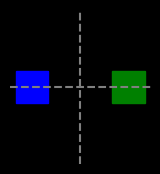

Distance between boxes calculated in different ways:
Box Coordinates:
	Box A: (-4.0, -1.0, -2.0, 1.0)
	Box B: (2.0, -1.0, 4.0, 1.0)
Bounds difference: [-6.  0. -6.  0.]
Shapely distance: 4.0
Hausdorff distance: 6.0
Frechet distance: 6.0


In [5]:
# 2 2x2 boxes
box2a = shapely.Polygon(box_points(2, offset_x=-3))
box2b = shapely.Polygon(box_points(2, offset_x=3))
plot_ab(box2a, box2b)
print("Distance between boxes calculated in different ways:")
print(f"Box Coordinates:\n\tBox A: {box2a.bounds}\n\tBox B: {box2b.bounds}")
print("Bounds difference:", np.array(box2a.bounds) - np.array(box2b.bounds))
print("Shapely distance:", shapely.distance(box2a, box2b))
print("Hausdorff distance:", shapely.hausdorff_distance(box2a, box2b))
print("Frechet distance:", shapely.frechet_distance(box2a, box2b))

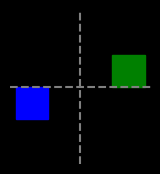

Distance between boxes calculated in different ways:
Box Coordinates:
	Box A: (-4.0, 0.0, -2.0, 2.0)
	Box B: (2.0, -2.0, 4.0, 0.0)
Bounds difference: [-6.  2. -6.  2.]
Shapely distance: 4.0
Hausdorff distance: 6.324555320336759
Frechet distance: 6.324555320336759


In [6]:
# 2 2x2 shifted boxes
box2a = shapely.Polygon(box_points(2, offset_x=-3, offset_y=1))
box2b = shapely.Polygon(box_points(2, offset_x=3, offset_y=-1))
plot_ab(box2a, box2b)
print("Distance between boxes calculated in different ways:")
print(f"Box Coordinates:\n\tBox A: {box2a.bounds}\n\tBox B: {box2b.bounds}")
print("Bounds difference:", np.array(box2a.bounds) - np.array(box2b.bounds))
print("Shapely distance:", shapely.distance(box2a, box2b))
print("Hausdorff distance:", shapely.hausdorff_distance(box2a, box2b))
print("Frechet distance:", shapely.frechet_distance(box2a, box2b))

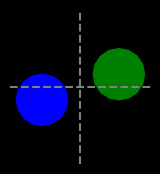

Distance between boxes calculated in different ways:
Box Coordinates:
	Box A: (-5.0, -1.0, -1.0, 3.0)
	Box B: (1.0, -3.0, 5.0, 1.0)
Bounds difference: [-6.  2. -6.  2.]
Shapely distance: 2.3514497655701683
Hausdorff distance: 6.324555320336759
Frechet distance: 6.324555320336759


In [7]:
# 2 2x2 shifted boxes
circle_a = shapely.Polygon(circle_points(2, offset_x=-3, offset_y=1))
circle_b = shapely.Polygon(circle_points(2, offset_x=3, offset_y=-1))
plot_ab(circle_a, circle_b)
print("Distance between boxes calculated in different ways:")
print(f"Box Coordinates:\n\tBox A: {circle_a.bounds}\n\tBox B: {circle_b.bounds}")
print("Bounds difference:", np.array(circle_a.bounds) - np.array(circle_b.bounds))
print("Shapely distance:", shapely.distance(circle_a, circle_b))
print("Hausdorff distance:", shapely.hausdorff_distance(circle_a, circle_b))
print("Frechet distance:", shapely.frechet_distance(circle_a, circle_b))

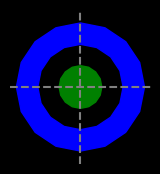

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-1.0, -1.0, 1.0, 1.0)
Bounds difference: [-2. -2.  2.  2.]
Shapely distance: 0.9804322967014896
Hausdorff distance: 2.0000822483088037
Frechet distance: 2.948805351324499


In [8]:
circle6 = shapely.Polygon(circle_points(3))
circle4 = shapely.Polygon(circle_points(2))
circle2 = shapely.Polygon(circle_points(1))

ring_a = circle6 - circle4
circle_b = circle2
plot_ab(ring_a, circle_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {ring_a.bounds}\n\tCircle B: {circle_b.bounds}")
print("Bounds difference:", np.array(ring_a.bounds) - np.array(circle_b.bounds))
print("Shapely distance:", shapely.distance(ring_a, circle_b))
print("Hausdorff distance:", shapely.hausdorff_distance(ring_a, circle_b))
print("Frechet distance:", shapely.frechet_distance(ring_a, circle_b))

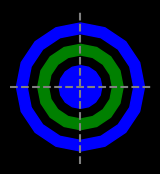

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-2.0, -2.0, 2.0, 2.0)
Bounds difference: [-1. -1.  1.  1.]
Shapely distance: 0.4903088029200839
Hausdorff distance: 1.0002324729781569
Frechet distance: 2.4540725335653795


In [9]:
circle6 = shapely.Polygon(circle_points(3))
circle5 = shapely.Polygon(circle_points(2.5))
circle4 = shapely.Polygon(circle_points(2))
circle3 = shapely.Polygon(circle_points(1.5))
circle2 = shapely.Polygon(circle_points(1))

ring_dot_a = (circle6 - circle5).union(circle2)
ring_b = circle4 - circle3

plot_ab(ring_dot_a, ring_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {ring_dot_a.bounds}\n\tCircle B: {ring_b.bounds}")
print("Bounds difference:", np.array(ring_dot_a.bounds) - np.array(ring_b.bounds))
print("Shapely distance:", shapely.distance(ring_dot_a, ring_b))
print("Hausdorff distance:", shapely.hausdorff_distance(ring_dot_a, ring_b))
print("Frechet distance:", shapely.frechet_distance(ring_dot_a, ring_b))

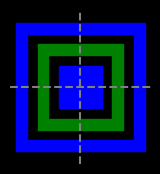

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-2.0, -2.0, 2.0, 2.0)
Bounds difference: [-1. -1.  1.  1.]
Shapely distance: 0.5
Hausdorff distance: 1.4142135623730951
Frechet distance: 5.0990195135927845


In [10]:
box6 = shapely.Polygon(box_points(6))
box5 = shapely.Polygon(box_points(5))
box4 = shapely.Polygon(box_points(4))
box3 = shapely.Polygon(box_points(3))
box2 = shapely.Polygon(box_points(2))

ring_box_a = (box6 - box5).union(box2)
box_ring_b = box4 - box3

plot_ab(ring_box_a, box_ring_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {ring_box_a.bounds}\n\tCircle B: {box_ring_b.bounds}")
print("Bounds difference:", np.array(ring_box_a.bounds) - np.array(box_ring_b.bounds))
print("Shapely distance:", shapely.distance(ring_box_a, box_ring_b))
print("Hausdorff distance:", shapely.hausdorff_distance(ring_box_a, box_ring_b))
print("Frechet distance:", shapely.frechet_distance(ring_box_a, box_ring_b))

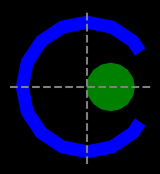

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 2.436989745200003, 3.0)
	Circle B: (0.0, -1.0, 2.0, 1.0)
Bounds difference: [-3.         -2.          0.43698975  2.        ]
Shapely distance: 0.7250695536892662
Hausdorff distance: 3.0
Frechet distance: 3.0


In [12]:
circle6 = shapely.Polygon(circle_points(3))
circle5 = shapely.Polygon(circle_points(2.5))
circle4_offset = shapely.Polygon(circle_points(2, offset_x=3.5))
shell = shapely.difference(circle6, circle5)
cove = shapely.difference(shell, circle4_offset)
circle2 = shapely.Polygon(circle_points(1, offset_x=1))

plot_ab(cove, circle2)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {cove.bounds}\n\tCircle B: {circle2.bounds}")
print("Bounds difference:", np.array(cove.bounds) - np.array(circle2.bounds))
print("Shapely distance:", shapely.distance(cove, circle2))
print("Hausdorff distance:", shapely.hausdorff_distance(cove, circle2))
print("Frechet distance:", shapely.frechet_distance(cove, circle2))

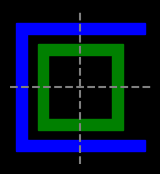

Distance between boxes calculated in different ways:
Circle Bounds:
	Ring A: (-3.0, -3.0, 3.0, 3.0)
	Circle B: (-3.0, -3.0, 3.0, 3.0)
Bounds difference: [0. 0. 0. 0.]
Shapely distance: 0.5
Hausdorff distance: 1.4142135623730951
Frechet distance: 4.743416490252569


In [13]:
box6 = shapely.Polygon(box_points(6))
box5 = shapely.Polygon(box_points(width=7, height=5, offset_x=1))
box4 = shapely.Polygon(box_points(4))
box3 = shapely.Polygon(box_points(3))
box2 = shapely.Polygon(box_points(2))

box_cove_a = (box6 - box5)
box_ring_b = box4 - box3

plot_ab(box_cove_a, box_ring_b)
print("Distance between boxes calculated in different ways:")
print(f"Circle Bounds:\n\tRing A: {box_cove_a.bounds}\n\tCircle B: {box_cove_a.bounds}")
print("Bounds difference:", np.array(box_cove_a.bounds) - np.array(box_cove_a.bounds))
print("Shapely distance:", shapely.distance(box_cove_a, box_ring_b))
print("Hausdorff distance:", shapely.hausdorff_distance(box_cove_a, box_ring_b))
print("Frechet distance:", shapely.frechet_distance(box_cove_a, box_ring_b))